# Section 5: Use the Sampler Primitive

### References

- https://quantum.cloud.ibm.com/docs/en/guides/primitives
- https://quantum.cloud.ibm.com/docs/en/guides/primitive-input-output
- https://quantum.cloud.ibm.com/docs/en/guides/simulate-with-qiskit-sdk-primitives
- https://quantum.cloud.ibm.com/docs/en/guides/get-started-with-primitives
- https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques
- https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/options-sampler-options
- https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/options-twirling-options

## What is a Primitive?

A primitive is the smallest processing instruction, the simplest building block from which one can create something useful for a given abstraction level.

When a need for a higher-level abstraction emerged to access the QPUs in the cloud, Qiskit introduced the primitives interface, which is optimized for two core tasks in quantum algorithm development: expectation value estimation (Estimator) and circuit sampling (Sampler). The purpose was to help developers to focus more on innovation and less on data conversion.

- Estimator computes expectation values of observables with respect to states prepared by quantum circuits.
- Sampler samples the output register from quantum circuit execution.

With Qiskit Runtime Primitives, we can also take advantage of the latest advancements in error mitigation and suppression by toggling options such as the primitive's resilience_level, rather than building our own implementation of these techniques.

## What are Base classes?

The Base primitives are abstract classes that define a common interface for implementing primitives. These classes might also be useful for those who want to do highly customized processing and find that the existing primitives implementations are too simple for their needs. General users will not directly use the base classes. They are:

- BaseEstimatorV2
- BaseSamplerV2

#### Note: Base classes are not relevant for the exam

## Implementations of the primitives base classes

#### 1. Qiskit Runtime Primitives - EstimatorV2 and SamplerV2
- These are used for real IBM Quantum hardware via the qiskit-ibm-runtime package.

#### 2. Reference Primitives - StatevectorEstimator and StatevectorSampler
- They use the simulator built into Qiskit. They are built with the Qiskit quantum_info module, producing results based on ideal statevector simulations. They are accessed through Qiskit.

#### 3. Backend Primitives - BackendEstimatorV2 and BackendSamplerV2
- They are used to “wrap” any quantum computing resource into a primitive. This lets us write primitive-style code for providers that don’t yet have a primitives-based interface. These classes can be used just like the regular Sampler and Estimator, except they should be initialized with an additional backend argument for selecting which quantum computer to run on. They are accessed by using Qiskit.

## Primitive inputs

A data structure known as a **Primitive Unified Bloc (PUB)** is used to efficiently define vectorized workloads. These PUBs are the fundamental unit of work for workload execution. They are used as inputs to the run() method for the Sampler and Estimator primitives, which execute the defined workload as a job. Then, after the job has completed, the results are returned in a format that depends on the PUBs used and any specified options.

## Primitive Unified Bloc (PUB)

The main argument to the **run()** method is a list of tuples, each tuple is for one circuit being executed by the primitive. Each of these tuples is considered a PUB, and the required elements of each tuple in the list depends on the primitive used.

#### 1. Estimator PUB - It should contain at most four values.
- A single QuantumCircuit, which may contain one or more Parameter objects
- A list of one or more observables, which specify the expectation values to estimate, arranged into an array
- A collection of parameter values to bind the circuit against
- A target precision for expectation values to estimate (Optional)

#### 2. Sampler PUB - It should contain at most three values
- A single QuantumCircuit, which may contain one or more Parameter objects
- A collection of parameter values to bind the circuit against
- A number of shots to measure the circuit with (Optional). The real backend defaults to 4096 shots

## Primitive outputs

The **PrimitiveResult** object contains an iterable list of PubResult objects that contain the execution results for each PUB. For example, a job submitted with 20 PUBs will return a PrimitiveResult object that contains a list of 20 PubResults, one corresponding to each PUB.

#### 1. Estimator output

#### 2. Sampler output

## Sampler Output

When a Sampler job is completed successfully, the returned **PrimitiveResult** object contains a list of **SamplerPubResults**, one per PUB. The data bins of these SamplerPubResult objects are dict-like objects that contain one BitArray per ClassicalRegister in the circuit.

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler import generate_preset_pass_manager

# generate a ten-qubit GHZ circuit
circuit = QuantumCircuit(10)
circuit.h(0)
circuit.cx(range(0,9), range(1,10))

# append measurements with the `measure_all` method
circuit.measure_all()

# transpile the circuit
pm = generate_preset_pass_manager(optimization_level=1)
transpiled_circuit = pm.run(circuit)

sampler = StatevectorSampler()

# run the Sampler job and retrieve the results
job = sampler.run([transpiled_circuit])
result = job.result()

data = result[0].data
counts = data.meas.get_counts()
print(f"Counts: {counts}")

Counts: {'0000000000': 517, '1111111111': 507}


#### When a circuit contains more than one classical register, the results are stored in different BitArray objects. 

In [2]:
circuit = QuantumCircuit(
    qreg := QuantumRegister(10),
    alpha := ClassicalRegister(1, "alpha"),
    beta := ClassicalRegister(9, "beta")
)

circuit.h(0)
circuit.cx(range(0,9), range(1,10))

circuit.measure(0, alpha)
circuit.measure(range(1,10), beta)

transpiled_circuit = pm.run(circuit)

job = sampler.run([transpiled_circuit])
result = job.result()

data = result[0].data
print(f"BitArray for register 'alpha': {data.alpha}")
print(f"BitArray for register 'beta': {data.beta}")

BitArray for register 'alpha': BitArray(<shape=(), num_shots=1024, num_bits=1>)
BitArray for register 'beta': BitArray(<shape=(), num_shots=1024, num_bits=9>)


## Change run options and run multiple PUBs

By default, the reference Sampler performs an exact statevector calculation based on the quantum_info.Statevector class. However, this can be modified to introduce the effect of the sampling overhead (also known as "shot noise"). To help manage this overhead, the Sampler interface accepts a shots argument that can be defined at the PUB level. If you don't provide a shots value, the StatevectorSampler gives you the "perfect" math. If you do provide shots, it simulates the "messy" reality of running on a real chip.

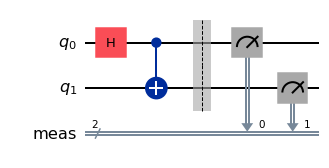

In [3]:
# Define quantum circuit with 2 qubits
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()
circuit.draw("mpl")

In [6]:
from qiskit.transpiler import generate_preset_pass_manager

# create two circuits
circuit1 = circuit.copy()
circuit2 = circuit.copy()

# transpile circuits
pm = generate_preset_pass_manager(optimization_level=1)
isa_circuit1 = pm.run(circuit1)
isa_circuit2 = pm.run(circuit2)

# execute 2 circuits using Sampler
job = sampler.run([(isa_circuit1), (isa_circuit2)], shots=1024)
pub_result_1 = job.result()[0]
pub_result_2 = job.result()[1]

data1 = pub_result_1.data.meas
data2 = pub_result_2.data.meas

counts1 = data1.get_counts()
print(f"Counts Circuit 1: {counts1}")

counts2 = data2.get_counts()
print(f"Counts Circuit 1: {counts2}")

Counts Circuit 1: {'00': 540, '11': 484}
Counts Circuit 1: {'00': 511, '11': 513}


## Sampler on QiskitRuntimeService

In [11]:
# from qiskit_ibm_runtime import QiskitRuntimeService

# QiskitRuntimeService.save_account(
# token="API", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
# instance="CRN", # Optional
# overwrite=True
# )

In [12]:
service = QiskitRuntimeService()

In [13]:
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

**EfficientSU2 is a hardware-efficient ansatz (a template circuit) used primarily in Variational Quantum Algorithms like VQE or QAOA.**

It is "efficient" because it is designed to run well on near-term quantum computers (NISQ devices) by using gates that the hardware can execute natively with low error.

In [16]:
import numpy as np
from qiskit.circuit.library import EfficientSU2

circuit = EfficientSU2(127, entanglement="linear")
circuit.num_parameters

1016

In [17]:
circuit.measure_all()
param_values = np.random.rand(circuit.num_parameters)

In [18]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict([('sx', 3726), ('rz', 3036), ('cz', 1449), ('measure', 127), ('barrier', 1)])


In [19]:
backend.name

'ibm_fez'

In [20]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend) # job execution mode

In [21]:
job = sampler.run([(isa_circuit, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d7n1up5qrg3c738lrda0
>>> Job Status: QUEUED


In [22]:
result = job.result()

# Get results for the first (and only) PUB
pub_result = result[0]
print(
    f"First ten results for the 'meas' output register: {pub_result.data.meas.get_bitstrings()[:10]}"
)

First ten results for the 'meas' output register: ['1100001100110001001011101001001010100010010010011010100000001101000110000011000000000010000011001010000111001100010000011000000', '1101110101110010011010100000000010011110010000011001000000100000010101100001000011101000111011101100000010000101011101000101111', '0110101101101101001110000011000100100000010001000011000000101000100000110100000010010110111110010000000000010100001100100001000', '0110110110100000010010001101010100100010010010011001010101001101010000011010100000000001000110101011000100010110000000000011000', '0011100111011010110000100101100111101001001010001110100010000001000000100010000110000001110000000011000000110000000010011001100', '1110001010111100111110100110001111010101000001100010001000011000000011001000100110101100110001000010000000000100001000001100000', '1100000000100011011011101000011111011001110010100000010001000001001010000101010010100001000000000001101001100110001000000111000', '1010110111101001000101111011111

## Run a single experiment

In [28]:
from qiskit.circuit.library import IQP
from qiskit.quantum_info import random_hermitian

# random_hermitian is a utility function in Qiskit’s quantum_info module used to generate a random Hermitian matrix 
# (or Operator).

In [29]:
n_qubits = 127

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_qubits)

mat = np.real(random_hermitian(n_qubits, seed=1234))
circuit = IQP(mat)
circuit.measure_all()

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)

sampler = Sampler(backend)
job = sampler.run([isa_circuit])
result = job.result()

# Get results for the first (and only) PUB
pub_result = result[0]

## Run multiple experiments

In [31]:
import numpy as np
from qiskit.circuit.library import iqp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import random_hermitian
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

n_qubits = 127

service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=n_qubits
)

mats = [np.real(random_hermitian(n_qubits, seed=1234)) for _ in range(3)]
circuits = [IQP(mat) for mat in mats]
for circuit in circuits:
    circuit.measure_all()

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuits = pm.run(circuits)

sampler = Sampler(mode=backend)
job = sampler.run(isa_circuits)
result = job.result()

for idx, pub_result in enumerate(result):
    print(
        f" > First ten results for pub {idx}: {pub_result.data.meas.get_bitstrings()[:10]}"
    )

 > First ten results for pub 0: ['0111001000101101111011000010000000101010000000100000100001000000010000100000010000000001001001000000000000100000000000000000000', '0100001100100111000001001001000000110010010000100000011000100000100000000000110100000101001000000000000000011000000000100000000', '1111110000001010010011000000000100010000101000110000000000100000000010000001001101001000000010000001000000001000000001000000000', '0000010011001110000100100000100100000001010001000000101100100000110000000100100101000100001110000101000001000100000001011000000', '0100100000110000000011000101001110000011100000110001100000000001010001000000011001100000000000000000000000100000000000000000000', '1001010000010010001010000001010001110000011001000010000000000011000000001000000010001010110000000010000010001000000011111000010', '1001111011100100000100100011000100000000000100001000010000000011000000000100000000000000001100001001000000101000100001100000010', '0001110001101011011000000100111110100000010000000

## Fake Backend

FakeBackend (e.g., FakeManilaV2, FakeSherbrooke) is a mock of a specific real IBM quantum device.

Includes the real device's noise model, coupling map, basis gates, and properties — cloned from actual hardware
Behaves like a real backend in terms of API (can be used with transpile, backend.run(), etc.)
Useful for realistic noise simulation without using real quantum credits

In [32]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# Bell Circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Run the sampler job locally using FakeManilaV2
fake_manila = FakeManilaV2()
pm = generate_preset_pass_manager(backend=fake_manila, optimization_level=1)
isa_qc = pm.run(qc)

# You can use a fixed seed to get fixed results.
options = {"simulator": {"seed_simulator": 42}}
sampler = Sampler(mode=fake_manila, options=options)

result = sampler.run([isa_qc]).result()

## Aer Simulator

AerSimulator is a general-purpose, high-performance quantum circuit simulator from the qiskit-aer package. Does not mimic any specific real device unless explicitly configured. Best for: algorithm development, testing logic, performance benchmarking

In [33]:
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

# Bell Circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Run the sampler job locally using AerSimulator.
# Session syntax is supported but ignored because local mode doesn't support sessions.
aer_sim = AerSimulator()
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
isa_qc = pm.run(qc)
with Session(backend=aer_sim) as session:
    sampler = Sampler(mode=session)
    result = sampler.run([isa_qc]).result()

In [34]:
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

# Bell Circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

service = QiskitRuntimeService()

# Specify a QPU to use for the noise model
real_backend = service.backend("ibm_fez")
aer = AerSimulator.from_backend(real_backend)

# Run the sampler job locally using AerSimulator.
pm = generate_preset_pass_manager(backend=aer, optimization_level=1)
isa_qc = pm.run(qc)
sampler = Sampler(mode=aer)
result = sampler.run([isa_qc]).result()

use them together — AerSimulator can load a FakeBackend's noise model to get both Aer's speed/flexibility and realistic noise:

fake_backend = FakeSherbrooke()
sim = AerSimulator.from_backend(fake_backend)  # Aer + real device noise

## Sampler Options

These options control how the Qiskit Runtime Sampler executes circuits. In V2, they are structured under `sampler.options`.

| Group | Option | Description |
| :--- | :--- | :--- |
| **Global** | `default_shots` | The number of times to run each circuit per PUB. (Default: 4096). |
| **Global** | `max_execution_time` | Maximum time (sec) allowed for the job before it's killed. (Max: 10800). |
| **Execution** | `init_qubits` | If `True`, resets all qubits to $|0\rangle$ before every shot. |
| **Execution** | `rep_delay` | Delay between shots to allow for hardware thermal relaxation. |
| **Twirling** | `enable_gates` | Applies **Pauli Twirling** to 2-qubit gates to convert systematic errors into noise. |
| **Twirling** | `num_randomizations` | Number of unique twirled circuits to generate. Higher = better error suppression. |
| **Decoupling** | `enable` | Turns on **Dynamical Decoupling (DD)** to protect idle qubits from decoherence. |
| **Decoupling** | `sequence_type` | Type of DD sequence (e.g., `XX`, `XY4`). `XY4` is often more robust. |
| **Simulator** | `seed_simulator` | Used in local testing mode to make random results reproducible. |

In [35]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options import SamplerOptions

# 1. Create the Options object
options = SamplerOptions()

# 2. Set Execution options (Qubit state and timing)
options.default_shots = 1024
options.execution.init_qubits = True
options.execution.rep_delay = 0.00025 # In seconds

# 3. Set Error Suppression (Dynamical Decoupling)
# Essential for large circuits like IQP to protect idling qubits
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"
options.dynamical_decoupling.scheduling_method = "alap" # As Late As Possible

# 4. Set Twirling (Mitigating gate systematic errors)
options.twirling.enable_gates = True
options.twirling.num_randomizations = "auto"

# 5. Pass these options to the Sampler
sampler = Sampler(mode=backend, options=options)

print("Sampler options successfully configured for high-fidelity execution!")

Sampler options successfully configured for high-fidelity execution!


## Twirling Options

Twirling converts "coherent errors" (systematic tilts or over-rotations in gates) into "stochastic noise" (random bit flips). It makes the noise easier for other tools (like ZNE) to clean up.

| Option | Default (Sampler) | Description |
| :--- | :--- | :--- |
| **`enable_gates`** | `False` | Applies twirling to 2-qubit Clifford gates (like $CX$ or $ECR$). |
| **`enable_measure`** | `False` | Applies twirling to measurement instructions to mitigate readout errors. |
| **`num_randomizations`** | `"auto"` | Number of different random circuit variations to run. |
| **`shots_per_randomization`** | `"auto"` | How many shots to spend on each random variation. |
| **`strategy`** | `"active-accum"` | Determines which qubits get twirled during a gate layer. |

### 💡 Twirling Strategies Explained:
* **`active`**: Only the qubits involved in a gate in that layer are twirled.
* **`active-circuit`**: Any qubit that is part of *any* gate in the whole circuit is twirled in every layer.
* **`active-accum`**: Qubits are added to the twirling "pool" once they've been used in a gate. (Best balance).
* **`all`**: Every single qubit in the backend is twirled in every layer, regardless of use.

## Error Suppression techniques

- **Dynamical Decoupling (DD)**: Protects idle qubits. Dynamical decoupling works by inserting pulse sequences on idling qubits to approximately cancel out the effect of these errors. Each inserted pulse sequence amounts to an identity operation, but the physical presence of the pulses has the effect of suppressing errors.

- Dynamical decoupling is mainly useful for circuits containing gaps in which some qubits sit idle without any operations acting on them. If the operations in the circuit are packed very densely, such that all of the qubits are busy most of the time, then the addition of dynamical decoupling pulses might not improve performance. In fact, it could even worsen performance due to imperfections in the pulses themselves.

- **Pauli Twirling**: Randomizes gate errors. Works for both, but is often "auto-enabled" in the Estimator.

#### NOTE: Error Mitigation techniques are only used for Estimator